# Harmonic Oscillator Simulation
### A simulation that models Harmonic Oscillators and shows the difference between them being underdamped, overdamped, and critically damped. For this simulation, I will be using a mass (m) on a spring that is attached to a block/wall.

So, what is a harmonic oscillator? Believe it or not, we interact with them constantly. Someone bouncing on a pogo stick, riding a playground swing, strumming a guitar string, or even the vibration of our vocal cords when we speak, all of these are examples of harmonic oscillators. Even electronic circuits, such as LC circuits, behave like harmonic oscillators because their voltages and currents oscillate in the same way a mass on a spring does.

In short, a harmonic oscillator is a system that experiences oscillations due to a restoring force that is proportional to its displacement from equilibrium. A simpler way to say this is: it moves back and forth because a force always pulls it back toward its starting position.

We can derive the equation of motion for a harmonic oscillator using Hooke’s Law:

\begin{aligned}
(1)\quad & \boxed{F = -kx}
\end{aligned}

where $F$ is the restoring force, $k$ is the spring constant, and $x$ is the displacement from equilibrium. Hooke's Law tells us the force at a given displacement, but it does not describe how the system evolves over time. To do that, we can combine Newton's Second Law: $\vec{F} = m\vec{a}$ and Hooke's Law: $\vec{F} = -kx$. Doing so gives the equation:

\begin{aligned}
(2)\quad & \boxed{m\vec{a} = -kx}
\end{aligned}

If you have experience with calculus, you'll know that acceleration, velocity, and position are connected through their derivatives with respect to time. This relationship can be summarized as: $x(t) \xrightarrow{\frac{d}{dt}} v(t) \xrightarrow{\frac{d}{dt}} a(t)$. In other words, acceleration $a(t)$ is the second time derivative of position $x(t)$, which we write as $\ddot{x}(t)$. Using this knowledge, we can rewrite equation (2) as:

\begin{aligned}
(3)\quad & \boxed{m\ddot{x} = -kx}
\end{aligned}

However, this describes an ideal, undamped oscillator. Real systems lose energy due to friction or drag. A simple and common model for this is adding a damping force that is poportional to velocity $F_d = -b\dot{x}$. We have $-b\dot{x}$ be negative because it is opposing the motion. Accounting for that, we can finally get our equation for motion.

\begin{aligned}
(4)\quad & \boxed{m\ddot{x} = -kx - b\dot{x}}
\end{aligned}


Now this is where things get interesting. We can rewrite equation (4) as: $ m\ddot{x} + b\dot{x} + kx = 0$, doing so gives the following differential equation.

\begin{aligned}
(5)\quad & \boxed{\ddot{x} + \frac{b}{m}\dot{x} + \frac{k}{m}x = 0}
\end{aligned}

This is a second-order homogeneous differential equation describing a damped harmonic oscillator. It becomes much easier to analyze if we define two important qualities.
- The Natural Frequency: $\omega = \sqrt{\frac{k}{m}}$, which is the frequency the system would oscillate at with no damping.
- The Damping Constant: $\gamma = \frac{b}{2m}$, which measures how quickly energy is lost from the system.

With the above definitions, we can get an equation that describes the motion of a damped harmonic oscillator.

\begin{aligned}
(6)\quad & \boxed{\ddot{x} + 2\gamma\dot{x} + \omega^2x = 0}
\end{aligned}

Before moving on, a damped harmonic oscillator can be in either one of three states: underdamped, overdamped, and critically damped.
- Underdamped ($\gamma < \omega$): The system will oscillate, but the amplitude decreases over time as energy is lost. The mass on the spring will overshoot the equilibrium position repeatedly,
- Overdamped ($\gamma > \omega$): The system returns to equilibrium without oscillating. It moves more slowly, when compared to critically damped, toward its equilibrium position and will never overshoot.
- Critically Damped ($\gamma = \omega$): The system returns to equilibrium without oscillating. It will return to its equilibrium position within the quickest time possible.

Going back to where we left off with equation (6), we have a second-order homogeneous differential equation. A standard method for solving such equations is to assume an exponential solution with the form:

\begin{aligned}
(7)\quad & \boxed{x(t) = \mathcal{e}^{rt}}
\end{aligned}

where $r$ is a constant to be determined. Substituting this guess into equation (6) gives:

\begin{aligned}
(8)\quad & \boxed{r^2\mathcal{e}^{rt} + 2\gamma{r}\mathcal{e}^{rt} + \omega^2\mathcal{e}^{rt} = 0}
\end{aligned}

We can factor out $\mathcal{e}^{rt}$, leaving us with our characteristic equation:

\begin{aligned}
(9)\quad & \boxed{r^{2} + 2\gamma{r} + \omega^2 = 0}
\end{aligned}

Equation (9) determines the behavior of the system. If we solve it for r, we get the solution $r = -\gamma {\pm}\sqrt{\gamma^2-\omega^2}$.  If we take a look at this solution and use the definition of underedamped ($\gamma < \omega$), overdamped ($\gamma > \omega$), and critically damped ($\gamma = \omega$). We can get different solutions.
- Underdamped ($\gamma < \omega$): where $r = -\gamma \pm i\omega$ and $\omega = \sqrt(\omega^2 - \gamma^2)$. The solution to equation (9) becomes $\boxed{x(t) = \mathcal{e}^{-\gamma{t}}(Acos(\omega{t}) + Bsin(\omega{t}))}$.

- Overdamped ($\gamma > \omega$): where $r = -\gamma \pm \sqrt{\gamma^2 - \omega}$ The solution to equation (9) becomes $\boxed{x(t) = C\mathcal{e}^{rt} + D\mathcal{e}^{rt}}$.

- Critically Damped ($\gamma = \omega$): where $r = -\gamma$. The solution to equation (9) becomes $\boxed{x(t) = (A + Bt)\mathcal{e}^{-\gamma{t}}}$.

We now have all of the theoretical knowledge we need to simulate a harmonic oscillator. When writing the program, our numerical simulation will require rewriting the second-order differential equation as a system of firs-order differential equations. I'll highlight how I did that in the code below.

Underdamped        b= 1.000   reached equilibrium at t = 13.975 seconds
Overdamped         b=20.000   reached equilibrium at t = 13.509 seconds
Critically Damped  b= 6.325   reached equilibrium at t = 3.284 seconds


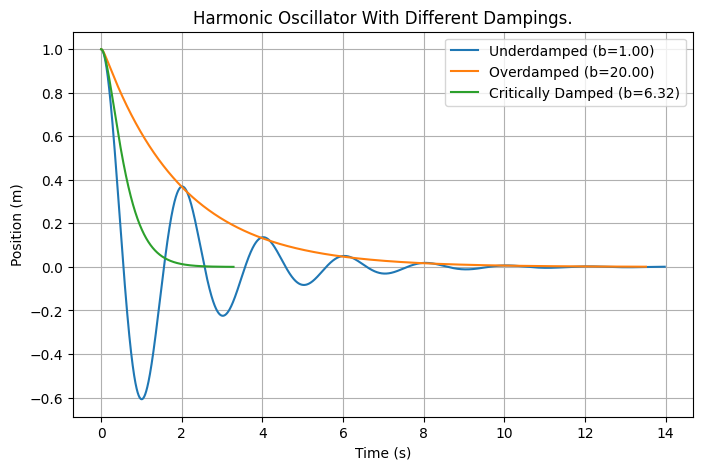

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------------------------------------------------------------------- #
# The function "derivative" is needed to rewrite the second-order ODE as a first-order ODE.
# If I start with equation (9), (x'' = 2y*x' + w^2*x = 0). and use (x'= dxdt = v) and (v' = dvdt = -2y*v - w^2*x)
# It can be converted into a more workable form.
# -------------------------------------------------------------------------------------------------------------------------------------- #

def derivative(state, gamma, omega):
    x = state[0] # This is the position.
    v = state[1] # This is the velocity.
    dxdt = v
    dvdt = -2*gamma*v - omega**2 * x
    return np.array([dxdt, dvdt]) # This stores x' and x'' values into an array, which is used below.

# -------------------------------------------------------------------------------------------------------------------------------------- #
# This function handles the simulation for the motion of a damped harmonic oscillator using euler's method.
# I start by defining gamma and omega using my notes from above. I chose some arbitrary values for m, k, and b.
# I might change things later so that you can use an inputted/slider value to change them to see how things change.
# Next, I classified the system as either: underdamped, overdamped, and critically damped based on the relation between gamma and omega.
# I have the simulation stop when each oscillator reaches it's equilibrium point, and then outputs the exact time.
# To be more specific, I defined the equilibrium point to mean x and v are very close.
# -------------------------------------------------------------------------------------------------------------------------------------- #

def HarmonicOscillator(m=1, k=10, b=10):

    # Computes the damping constant (gamma) and the natural frequency (omega).
    gamma = b/(2*m)
    omega = np.sqrt(k/m)

    # Labels each dampening type basedon the relation between gamma and omega.
    if gamma < omega:
        dampType = "Underdamped"
    elif gamma > omega:
        dampType = "Overdamped"
    else:
        dampType = "Critically Damped"

    # Settings for euler's method.    
    dt = 0.001           # small time step needed to make the method work.
    t = 0.0              # start time.
    t_f = 30.0           # added a max time limit to prevent code from running endlessly.
    equilPoint = 1e-3    # this is how close the x and v values need to be in order to be at equilibrium.


    # Initial conditions for initial position and inital velocity.
    x_0 = 1.0
    v_0 = 0.0

    # Initializes states
    positions = []
    velocities = []
    times = []

    # State vector that stores [x,v]
    state = np.array([x_0, v_0])

# -------------------------------------------------------------------------------------------------------------------------------------- #
# This is the Euler Integration Loop. It is used to solve the ODE equations by repeatedly:
# 1) Calculating derivatives (x',v')
# 2) Updating x and v using Euler's method.
# 3) Checking if the harmonic oscillator had reached equilibrium.
# This is the method I am most familiar with when dealing with loops.
# -------------------------------------------------------------------------------------------------------------------------------------- #
    
    while t < t_f:

        positions.append(state[0])
        velocities.append(state[1])
        times.append(t)

        # Computes derivatives from the above ODEs.
        dxdt, dvdt = derivative(state, gamma, omega)

        # Update steps.
        x = state[0]
        v = state[1]
        state[0] = x + dxdt * dt
        state[1] = v + dvdt * dt

        t += dt

        # Stops early when v and x are within the value of our "equilPoint" from above.
        # I did this as a way to show how quickly a critically damped oscillator reaches equilibrium compared to the others.
        if abs(state[0]) < equilPoint and abs(state[1]) < equilPoint:
            break

    # Returns values from our time, damping type, and time to equilibrium.
    return np.array(times), np.array(positions), np.array(velocities), dampType, times[-1]

# Damping cases, values used where to meet definition defined in notes at start of program.
cases = [
    ("Underdamped", 1),
    ("Overdamped", 20),
    ("Critically Damped", 2*np.sqrt(10))
]

# Plot all three regimes and print the time it takes to reach equilibrium.
# Values I used for the plot are arbitrary and what I find pleasant to look at.
plt.figure(figsize=(8,5))

for label, b in cases:
    t, x, v, dampType, t_eq = HarmonicOscillator(m=1, k=10, b=b)
    print(f"{dampType:17s}  b={b:6.3f}   reached equilibrium at t = {t_eq:.3f} seconds")
    plt.plot(t, x, label=f"{dampType} (b={b:.2f})")

plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Harmonic Oscillator With Different Dampings.")
plt.grid(True)
plt.legend()
plt.show()